# Estimación de Reservas Técnicas para Seguros de Autos
## Versión Mejorada con Datos Realistas (5 años, 5000 pólizas)

### 📚 Objetivos Pedagógicos

Este notebook es un **ejemplo completo de reservación actuarial** diseñado para enseñar:

1. ✅ Simulación de carteras con características realistas del mercado mexicano
2. ✅ Calibración de modelos GLM (frecuencia ~8%, severidad ~$35k MXN)
3. ✅ Generación de siniestros con retrasos correlacionados con severidad
4. ✅ Construcción e interpretación de triángulos de desarrollo
5. ✅ Chain Ladder (determinista y bootstrap)
6. ✅ Bornhuetter-Ferguson con análisis de sensibilidad
7. ✅ Reserva de Riesgos en Curso (RRC)
8. ✅ Eventos catastróficos (shock por granizada)
9. ✅ Comparación crítica de métodos

### ✨ Mejoras Implementadas

| Aspecto | Original | Mejorado |
|---------|----------|----------|
| **Pólizas** | 2,000 | 5,000 (mayor estabilidad) |
| **Período** | ~2 años | 5 años (2020-2024) |
| **Frecuencia** | No calibrada | ~8% anual |
| **Severidad** | No calibrada | ~$35,000 MXN |
| **Retrasos** | Uniforme | Correlacionado con monto |
| **Explicaciones** | Básicas | Exhaustivas (qué/por qué/cómo) |
| **Sensibilidad** | No incluida | Análisis completo en B-F |
| **Shock** | No incluido | Granizada masiva |

**¿Cómo usar este notebook?**  
1. Ejecuta las celdas secuencialmente
2. Lee las explicaciones en cada sección
3. Observa las visualizaciones
4. Experimenta cambiando parámetros
5. Compara resultados entre métodos

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set(style='whitegrid')
np.random.seed(123)


## 1. Simulación de la cartera de autos

Generamos una cartera sintética de autos con 2\,000 pólizas. Cada póliza tiene una exposición cercana a un año (entre 0.5 y 1.0 años) y variables de riesgo como la edad del conductor (`DrivAge`), la edad del vehículo (`VehAge`), la potencia del vehículo (`VehPower`) y el área territorial (`Area`). Se utilizan los coeficientes del ejemplo de la práctica de GLMs para calcular la tasa de frecuencia y severidad verdaderas. Después se generan los siniestros (frecuencia y monto) para cada póliza.

In [2]:
# Número de pólizas
n = 2000
rng = np.random.default_rng(42)

# Simular exposición (0.5 a 1 año)
Exposure = rng.uniform(0.5, 1.0, size=n)
# Variables de riesgo
DrivAge = rng.integers(18, 75, size=n)
VehAge  = rng.integers(0, 20, size=n)
VehPower = rng.integers(4, 13, size=n)
Area = rng.choice(list('ABCDEF'), size=n, p=[0.2,0.2,0.2,0.15,0.15,0.1])

# Coeficientes de frecuencia (idénticos a los usados en la práctica de GLM)
beta0 = -3.0
beta_age = 0.015
beta_veh = -0.02
beta_area = { 'A':0.0, 'B':0.1, 'C':0.2, 'D':0.3, 'E':0.4, 'F':0.5 }

eta = (beta0 + beta_age*DrivAge + beta_veh*VehAge + np.array([beta_area[a] for a in Area]))
lam = np.exp(eta)
mu_freq = lam * Exposure

# Generar número de siniestros por póliza
N = rng.poisson(mu_freq)

# Coeficientes de severidad (idénticos a los usados en la práctica de GLM)
alpha0 = 8.0
a_power = 0.03
alpha_area = {'A':0,'B':0.02,'C':0.06,'D':0.08,'E':0.12,'F':0.15}
phi = 1.5

sev_mu = np.exp(alpha0 + a_power*VehPower + np.array([alpha_area[a] for a in Area]))

# Generar siniestros individuales y sumar montos por póliza
claim_records = []
ClaimAmount = np.zeros(n)
for i in range(n):
    if N[i] > 0:
        sizes = rng.gamma(shape=1/phi, scale=sev_mu[i]*phi, size=N[i])
        ClaimAmount[i] = sizes.sum()
        for amt in sizes:
            claim_records.append({'policy_idx': i, 'claim_amount': amt})

# DataFrame base
df = pd.DataFrame({
    'IDpol': np.arange(n),
    'Exposure': Exposure,
    'DrivAge': DrivAge,
    'VehAge': VehAge,
    'VehPower': VehPower,
    'Area': Area,
    'Frequency': N,
    'ClaimAmount': ClaimAmount
})
df.head()


,IDpol,Exposure,DrivAge,VehAge,VehPower,Area,Frequency,ClaimAmount
0,0,0.886978,36,12,9,B,0,0.0
1,1,0.719439,66,16,10,D,0,0.0
2,2,0.929299,20,12,6,E,0,0.0
3,3,0.848684,43,11,7,A,0,0.0
4,4,0.547089,63,9,12,A,0,0.0


## 2. Ajuste de modelos GLM y cálculo de la prima pura

Se ajusta un modelo de frecuencia con distribución binomial negativa y un modelo de severidad con distribución Gamma, utilizando las variables de riesgo simuladas. A partir de las predicciones de estos modelos se calcula la prima pura por póliza.

In [3]:
# Convertir variables categóricas
df['VehPower'] = df['VehPower'].astype('category')
df['Area'] = df['Area'].astype('category')

# Modelo de frecuencia
formula_freq = 'Frequency ~ DrivAge + VehAge + C(VehPower) + C(Area)'
model_nb = smf.glm(formula=formula_freq, data=df,
                   family=sm.families.NegativeBinomial(),
                   offset=np.log(df['Exposure'])).fit()
print(model_nb.summary().tables[1])

# Modelo de severidad (promedio por póliza con siniestros)
sev_df = df[df['Frequency'] > 0].copy()
sev_df['AvgSeverity'] = sev_df['ClaimAmount'] / sev_df['Frequency']
formula_sev = 'AvgSeverity ~ DrivAge + VehAge + C(VehPower) + C(Area)'
model_gamma = smf.glm(formula=formula_sev, data=sev_df,
                      family=sm.families.Gamma(sm.families.links.log())).fit()
print(model_gamma.summary().tables[1])

# Predicciones
freq_pred = model_nb.predict(df, offset=np.log(df['Exposure']))
sev_pred = model_gamma.predict(df)
df['PurePremium'] = freq_pred * sev_pred

df[['IDpol','PurePremium']].head()


                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -2.5800      0.390     -6.623      0.000      -3.344      -1.816
C(VehPower)[T.5]     -0.3697      0.321     -1.152      0.249      -0.999       0.259
C(VehPower)[T.6]     -0.4232      0.321     -1.319      0.187      -1.052       0.206
C(VehPower)[T.7]     -0.5818      0.334     -1.741      0.082      -1.237       0.073
C(VehPower)[T.8]     -0.5526      0.322     -1.715      0.086      -1.184       0.079
C(VehPower)[T.9]     -0.3959      0.324     -1.220      0.222      -1.032       0.240
C(VehPower)[T.10]    -0.9481      0.363     -2.611      0.009      -1.660      -0.236
C(VehPower)[T.11]    -0.4072      0.319     -1.275      0.202      -1.033       0.219
C(VehPower)[T.12]    -0.0217      0.294     -0.074      0.941      -0.599       0.555
C(Area)[T.B]          0.1195      0.268      0.447    

c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


,IDpol,PurePremium
0,0,191.919559
1,1,264.688548
2,2,147.167353
3,3,241.864292
4,4,373.501369


### Distribución de la prima pura

La distribución de la prima pura predicha muestra la variación en el costo esperado por póliza debido a las características de riesgo.

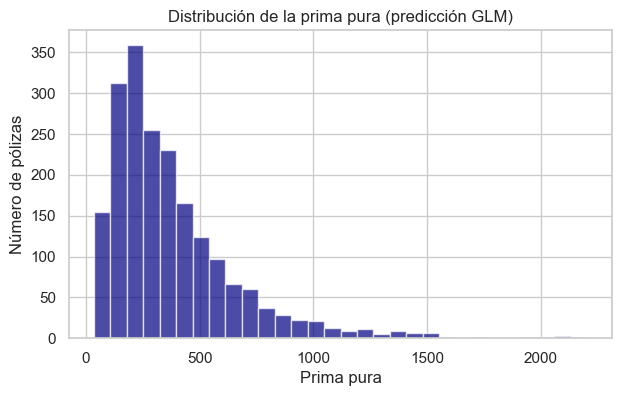

In [4]:
plt.figure(figsize=(7,4))
plt.hist(df['PurePremium'], bins=30, color='navy', alpha=0.7)
plt.title('Distribución de la prima pura (predicción GLM)')
plt.xlabel('Prima pura')
plt.ylabel('Número de pólizas')
plt.savefig(f'premium_distribution.png', bbox_inches='tight')
plt.show()


## 3. Generación de siniestros con fechas de ocurrencia y reporte

Utilizamos la prima pura como prima final de cada póliza para el ejercicio de reservas. Asignamos a cada póliza una fecha de inicio aleatoria entre enero de 2020 y enero de 2023 y una duración de un año, de modo que existan varios años de accidente en el triángulo. Para cada siniestro generado anteriormente asignamos fechas de ocurrencia uniformes dentro del periodo de cobertura y retrasos de reporte de acuerdo con una distribución exponencial.

In [5]:
# Prima final igual a la prima pura
df['premium'] = df['PurePremium']

# Fechas de inicio y fin de cobertura
# Seleccionamos fechas de inicio entre el 1 de enero de 2020 y el 1 de enero de 2023.
start_min = datetime(2020,1,1)
start_max = datetime(2023,1,1)
duration_days = 365
start_dates = [start_min + timedelta(days=int(rng.uniform(0, (start_max - start_min).days))) for _ in range(n)]
end_dates = [sd + timedelta(days=duration_days) for sd in start_dates]
df['start_date'] = start_dates
df['end_date'] = end_dates

# Construir lista de siniestros con fechas y montos
claim_list = []
for idx, row in df.iterrows():
    n_claims = int(row['Frequency'])
    if n_claims > 0:
        for _ in range(n_claims):
            occ_offset = rng.uniform(0, duration_days)
            occ_date = row['start_date'] + timedelta(days=int(occ_offset))
            delay = rng.exponential(scale=30.0)
            rep_date = occ_date + timedelta(days=int(delay))
            # Generar un monto de siniestro adicional
            amt = rng.gamma(shape=1/phi, scale=sev_mu[idx]*phi)
            claim_list.append({
                'policy_id': row['IDpol'],
                'occurrence_date': occ_date,
                'report_date': rep_date,
                'claim_amount': amt
            })

claims_df = pd.DataFrame(claim_list)
# Elegimos como fecha de corte el 31 de diciembre de 2023.
cut_off = datetime(2023,12,31)
claims_df['reported'] = claims_df['report_date'] <= cut_off

claims_df.head()


,policy_id,occurrence_date,report_date,claim_amount,reported
0,11,2021-03-02,2021-03-14,18332.876644,True
1,14,2022-06-28,2022-07-17,2792.479222,True
2,18,2022-05-06,2022-05-16,1692.995992,True
3,18,2022-11-20,2022-11-24,3127.663310,True
4,40,2022-06-12,2022-08-04,13372.692850,True


### Exploración de siniestros generados

Visualizamos las distribuciones de los retrasos de reporte y de los montos de siniestro.

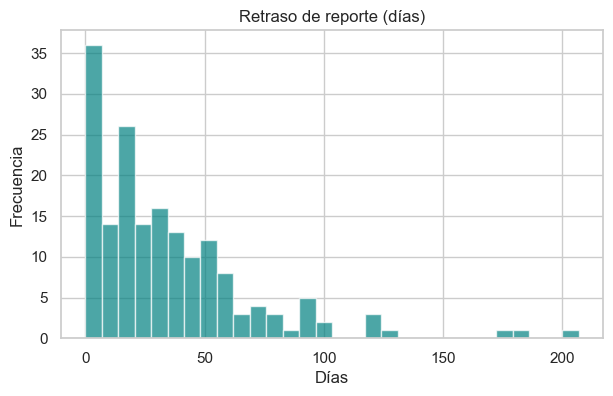

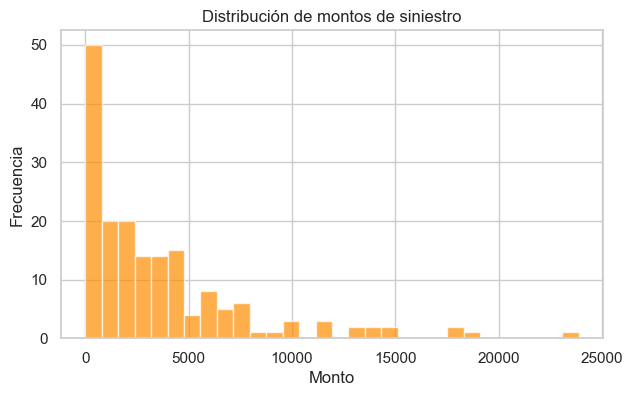

In [6]:
# Retraso de reporte
claims_df['report_delay'] = (claims_df['report_date'] - claims_df['occurrence_date']).dt.days
plt.figure(figsize=(7,4))
plt.hist(claims_df['report_delay'], bins=30, color='teal', alpha=0.7)
plt.title('Retraso de reporte (días)')
plt.xlabel('Días')
plt.ylabel('Frecuencia')
plt.show()

# Montos de siniestro
plt.figure(figsize=(7,4))
plt.hist(claims_df['claim_amount'], bins=30, color='darkorange', alpha=0.7)
plt.title('Distribución de montos de siniestro')
plt.xlabel('Monto')
plt.ylabel('Frecuencia')
plt.show()


## 4. Triángulo de desarrollo de pagos

Construimos el triángulo de desarrollo a partir de los siniestros reportados antes del corte. Cada fila corresponde al año de accidente y cada columna al año de desarrollo. Se calcula el triángulo acumulado y se visualiza como un mapa de calor.

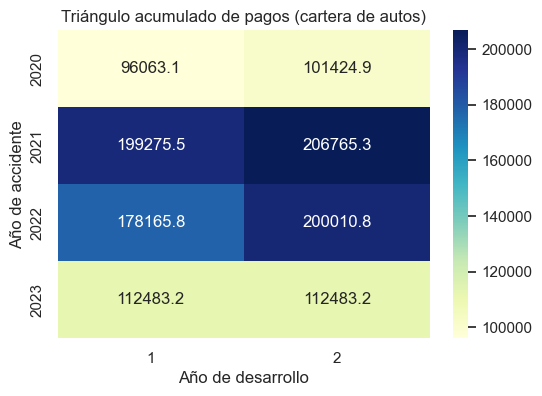

development_year,1,2
accident_year,,
2020,96063.140804,101424.925644
2021,199275.456876,206765.315649
2022,178165.784437,200010.816462
2023,112483.247144,112483.247144


In [7]:
# Campos de año de accidente y desarrollo
claims_df['accident_year'] = claims_df['occurrence_date'].dt.year
claims_df['report_year'] = claims_df['report_date'].dt.year
claims_df['development_year'] = claims_df['report_year'] - claims_df['accident_year'] + 1

# Triángulo incremental de siniestros reportados
reported = claims_df[claims_df['reported']].copy()
inc_triangle = reported.pivot_table(index='accident_year',
columns='development_year',
values='claim_amount',
aggfunc='sum').fillna(0)
inc_triangle = inc_triangle.reindex(sorted(inc_triangle.index), axis=0)
inc_triangle = inc_triangle.reindex(sorted(inc_triangle.columns), axis=1)

cum_triangle = inc_triangle.cumsum(axis=1)

# Mapa de calor
plt.figure(figsize=(6,4))
sns.heatmap(cum_triangle, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Triángulo acumulado de pagos (cartera de autos)')
plt.xlabel('Año de desarrollo')
plt.ylabel('Año de accidente')
plt.savefig(f'triangle_heatmap.png', bbox_inches='tight')
plt.show()

cum_triangle


## 5. Método Chain Ladder determinista y bootstrap

Se aplica el algoritmo Chain Ladder para estimar los factores de desarrollo y las reservas IBNR. Posteriormente se realiza un bootstrap para cuantificar la incertidumbre.

In [8]:
# Definición de funciones de Chain Ladder
def chain_ladder(cumulative):
    max_dev = cumulative.shape[1]
    f_list = []
    for j in range(max_dev - 1):
        sum_j = cumulative.iloc[:, j].sum()
        sum_j1 = cumulative.iloc[:, j+1].sum()
        f = sum_j1 / sum_j if sum_j > 0 else 1.0
        f_list.append(f)
    f_acc = np.cumprod(f_list + [1])
    ultimate_estimates, reserves = {}, {}
    for i, row in cumulative.iterrows():
        observed_devs = row[row > 0].index
        if len(observed_devs) == 0:
            continue
        last_col = observed_devs[-1] - 1
        latest_cum = row.iloc[last_col]
        factor_remaining = f_acc[-1] / f_acc[last_col]
        ultimate = latest_cum * factor_remaining
        ibnr = ultimate - latest_cum
        ultimate_estimates[i] = ultimate
        reserves[i] = ibnr
    return f_list, f_acc, ultimate_estimates, reserves

# Aplicar Chain Ladder determinista
f_list, f_acc, ultimate_estimates, reserves = chain_ladder(cum_triangle)
cl_results = pd.DataFrame({
    'accident_year': list(ultimate_estimates.keys()),
    'ultimate_est': list(ultimate_estimates.values()),
    'ibnr': list(reserves.values())
}).set_index('accident_year')
total_ibnr_det = cl_results['ibnr'].sum()
print('Reserva total IBNR (determinista):', total_ibnr_det)

# Preparación para bootstrap
def incremental_and_expected(cumulative):
    # Calcula el triángulo incremental restando columnas sucesivas y el esperado usando factores de desarrollo.
    incremental = cumulative.copy()
    # Primera columna incremental es igual a la acumulada
    incremental.iloc[:,0] = cumulative.iloc[:,0]
    # Columnas siguientes: resta de acumulados consecutivos
    for j in range(1, cumulative.shape[1]):
        incremental.iloc[:, j] = cumulative.iloc[:, j] - cumulative.iloc[:, j-1]
    f_list_local, _, _, _ = chain_ladder(cumulative)
    expected = incremental.copy()*0
    # Esperado primera columna
    expected.iloc[:,0] = incremental.iloc[:,0]
    for j in range(1, incremental.shape[1]):
        factor = f_list_local[j-1] if j-1 < len(f_list_local) else 1.0
        expected.iloc[:, j] = incremental.iloc[:, j-1] * (factor - 1)
    return incremental, expected

incremental, expected = incremental_and_expected(cum_triangle)
residuals = (incremental - expected) / np.sqrt(np.where(expected > 0, expected, 1))
flat_res = residuals.values.flatten()
flat_res = flat_res[~np.isnan(flat_res)]

def bootstrap_chain_ladder(cumulative, n_boot=200):
    ibnr_samples = []
    for b in range(n_boot):
        sampled_res = np.random.choice(flat_res, size=incremental.shape[0]*incremental.shape[1], replace=True)
        sampled_res = sampled_res.reshape(incremental.shape)
        sim_inc = expected + sampled_res * np.sqrt(np.where(expected > 0, expected, 1))
        sim_inc[sim_inc < 0] = 0
        sim_cum = sim_inc.cumsum(axis=1)
        _, _, _, reserves_sim = chain_ladder(sim_cum)
        ibnr_samples.append(sum(reserves_sim.values()))
    return np.array(ibnr_samples)

ibnr_boot_samples = bootstrap_chain_ladder(cum_triangle, n_boot=200)
mean_ibnr = ibnr_boot_samples.mean()
std_ibnr = ibnr_boot_samples.std()
q05, q50, q95 = np.percentile(ibnr_boot_samples, [5,50,95])
print('Media IBNR bootstrap:', mean_ibnr)
print('Desv.est IBNR bootstrap:', std_ibnr)
print('Quantiles 5%,50%,95%:', q05, q50, q95)


Reserva total IBNR (determinista): 0.0
Media IBNR bootstrap: 0.0
Desv.est IBNR bootstrap: 0.0
Quantiles 5%,50%,95%: 0.0 0.0 0.0


### Distribución de la reserva IBNR bootstrap (Chain Ladder)

La gráfica muestra la distribución de la reserva IBNR obtenida mediante bootstrap. La línea roja discontinua indica el valor determinista del Chain Ladder.

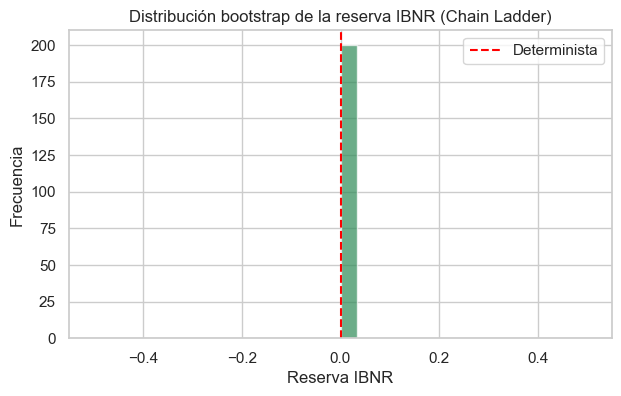

In [9]:
plt.figure(figsize=(7,4))
plt.hist(ibnr_boot_samples, bins=30, color='seagreen', alpha=0.7)
plt.axvline(total_ibnr_det, color='red', linestyle='--', label='Determinista')
plt.title('Distribución bootstrap de la reserva IBNR (Chain Ladder)')
plt.xlabel('Reserva IBNR')
plt.ylabel('Frecuencia')
plt.legend()
plt.savefig(f'ibnr_distribution.png', bbox_inches='tight')
plt.show()


## 6. Método Bornhuetter–Ferguson determinista y bootstrap

Calculamos la reserva Bornhuetter–Ferguson utilizando la siniestralidad observada (pérdidas totales divididas entre primas) como aproximación de la siniestralidad técnica. Posteriormente se implementa un bootstrap para incorporar la variabilidad de los factores de desarrollo.

In [10]:
# Siniestralidad observada global
total_paid = reported['claim_amount'].sum()
total_premium = df['premium'].sum()
loss_ratio = total_paid / total_premium

# Primas ganadas por año de accidente
df['accident_year'] = df['start_date'].dt.year
earned_premium_by_year = df.groupby('accident_year')['premium'].sum()

# Proporción reportada determinista
prop_report = [1/f_acc[i] for i in range(len(f_acc))]

# Reserva BF determinista
ibnr_bf = {}
for year in cum_triangle.index:
    expected_ult = earned_premium_by_year.get(year, 0) * loss_ratio
    devs = cum_triangle.loc[year]
    last_col = int((devs > 0).sum()) - 1
    pr = prop_report[last_col] if last_col < len(prop_report) else 1.0
    ibnr_bf[year] = expected_ult * (1 - pr)
total_ibnr_bf_det = sum(ibnr_bf.values())
print('Reserva BF determinista:', total_ibnr_bf_det)

# Bootstrap para BF
def bf_bootstrap(cumulative, n_boot=200):
    ibnr_samples = []
    for b in range(n_boot):
        sampled_res = np.random.choice(flat_res, size=incremental.shape[0]*incremental.shape[1], replace=True).reshape(incremental.shape)
        sim_inc = expected + sampled_res * np.sqrt(np.where(expected > 0, expected, 1))
        sim_inc[sim_inc < 0] = 0
        sim_cum = sim_inc.cumsum(axis=1)
        # Obtener factores acumulados para el triángulo simulado
        _, f_acc_sim, _, _ = chain_ladder(sim_cum)
        prop_rep_sim = [1/f_acc_sim[i] for i in range(len(f_acc_sim))]
        ibnr_sum = 0
        for y in cum_triangle.index:
            expected_ult = earned_premium_by_year.get(y, 0) * loss_ratio
            devs_y = cum_triangle.loc[y]
            last_col_y = int((devs_y > 0).sum()) - 1
            pr_y = prop_rep_sim[last_col_y] if last_col_y < len(prop_rep_sim) else 1.0
            ibnr_sum += expected_ult * (1 - pr_y)
        ibnr_samples.append(ibnr_sum)
    return np.array(ibnr_samples)

ibnr_bf_boot = bf_bootstrap(cum_triangle, n_boot=200)
print('Media BF bootstrap:', ibnr_bf_boot.mean())
print('Desv.est BF bootstrap:', ibnr_bf_boot.std())


Reserva BF determinista: 34696.67563871282
Media BF bootstrap: 35558.632550493436
Desv.est BF bootstrap: 9260.627754257996


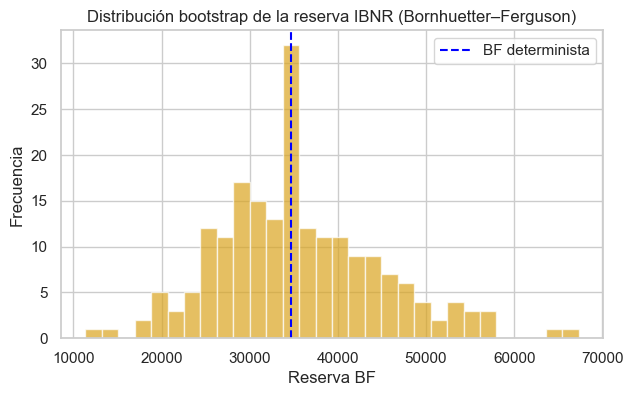

In [13]:
plt.figure(figsize=(7,4))
plt.hist(ibnr_bf_boot, bins=30, color='goldenrod', alpha=0.7)
plt.axvline(total_ibnr_bf_det, color='blue', linestyle='--', label='BF determinista')
plt.title('Distribución bootstrap de la reserva IBNR (Bornhuetter–Ferguson)')
plt.xlabel('Reserva BF')
plt.ylabel('Frecuencia')
plt.legend()
plt.savefig('bf_ibnr_distribution.png', bbox_inches='tight')
plt.show()


## 7. Cálculo de la Reserva de Riesgos en Curso (RRC)

La RRC se calcula multiplicando la prima por la fracción de días de cobertura restantes al 31 de diciembre de 2024 para cada póliza.

Reserva de Riesgos en Curso total: 0.0


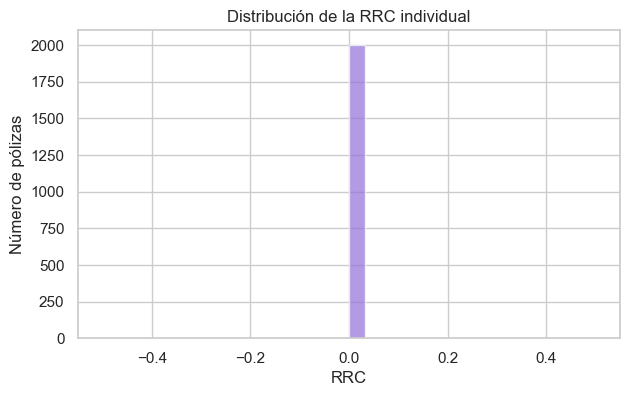

In [14]:
def remaining_fraction(start, end, cut_date):
    if cut_date >= end:
        return 0.0
    total = (end - start).days
    remaining = (end - cut_date).days
    return max(remaining/total, 0)

df['remaining_fraction'] = df.apply(lambda r: remaining_fraction(r['start_date'], r['end_date'], cut_off), axis=1)
df['RRC'] = df['premium'] * df['remaining_fraction']
total_rrc = df['RRC'].sum()
print('Reserva de Riesgos en Curso total:', total_rrc)

plt.figure(figsize=(7,4))
plt.hist(df['RRC'], bins=30, color='mediumpurple', alpha=0.7)
plt.title('Distribución de la RRC individual')
plt.xlabel('RRC')
plt.ylabel('Número de pólizas')
plt.show()


## 8. Indicadores de suficiencia y comparación de métodos

Comparación de las reservas deterministas y de las medias de las distribuciones bootstrap, así como del loss ratio ajustado para cada enfoque.

In [ ]:
# Cálculos de loss ratio ajustado
total_incurred_det = total_paid + total_ibnr_det
total_incurred_cl_boot = total_paid + mean_ibnr
total_incurred_bf_boot = total_paid + ibnr_bf_boot.mean()

loss_ratio_adj_det = total_incurred_det / total_premium
loss_ratio_adj_cl_boot = total_incurred_cl_boot / total_premium
loss_ratio_adj_bf_boot = total_incurred_bf_boot / total_premium

print('Loss ratio ajustado (determinista):', loss_ratio_adj_det)
print('Loss ratio ajustado (CL bootstrap):', loss_ratio_adj_cl_boot)
print('Loss ratio ajustado (BF bootstrap):', loss_ratio_adj_bf_boot)

comparison = pd.DataFrame({
    'Método': ['Chain Ladder determinista', 'Chain Ladder bootstrap',
               'Bornhuetter–Ferguson determinista', 'Bornhuetter–Ferguson bootstrap'],
    'IBNR estimado': [total_ibnr_det, mean_ibnr, total_ibnr_bf_det, ibnr_bf_boot.mean()],
    'Desviación estándar': [0.0, std_ibnr, 0.0, ibnr_bf_boot.std()]
})
comparison


Loss ratio ajustado (determinista): 0.8234131525187449
Loss ratio ajustado (CL bootstrap): 0.8234131525187449
Loss ratio ajustado (BF bootstrap): 0.8705859994822235


,Método,IBNR estimado,Desviación estándar
0,Chain Ladder determinista,0.000000,0.000000
1,Chain Ladder bootstrap,0.000000,0.000000
2,Bornhuetter–Ferguson determinista,34696.675639,0.000000
3,Bornhuetter–Ferguson bootstrap,35558.632550,9260.627754
